<a href="https://colab.research.google.com/github/AliRaddman/ai-bootcamp-DeepLearning/blob/main/notebooks/cv/05_cv_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# مرحله پنجم: ارزیابی و مقایسه مدل‌ها

در این Notebook عملکرد دو مدل زیر مقایسه می‌شود:

- مدل پایه: ResNet18 با Mean Pooling
- مدل زمانی

مقایسه با استفاده از پیش‌بینی‌های یکسان روی مجموعه Validation انجام می‌شود.

فایل‌های ورودی:

- `baseline_validation_predictions.csv`
- `temporal_validation_predictions.csv`

در اولین مرحله، ساختار فایل‌ها، تعداد نمونه‌ها، شناسه ویدئوها و تطابق برچسب‌های واقعی بررسی می‌شود.

</div>

In [1]:
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/AI_Project2")
CV_OUTPUT_DIR = PROJECT_ROOT / "outputs/cv"

BASELINE_PREDICTIONS_PATH = (
    CV_OUTPUT_DIR / "baseline_validation_predictions.csv"
)

TEMPORAL_PREDICTIONS_PATH = (
    CV_OUTPUT_DIR / "temporal_validation_predictions.csv"
)

required_columns = {
    "video_id",
    "true_label",
    "predicted_label",
    "predicted_probability",
}

baseline_df = pd.read_csv(
    BASELINE_PREDICTIONS_PATH,
    dtype={"video_id": str}
)

temporal_df = pd.read_csv(
    TEMPORAL_PREDICTIONS_PATH,
    dtype={"video_id": str}
)

# یکسان‌سازی شناسه ویدئوها
for dataframe in [baseline_df, temporal_df]:
    dataframe["video_id"] = (
        dataframe["video_id"]
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(5)
    )

print("Baseline columns:")
print(baseline_df.columns.tolist())

print("\nTemporal columns:")
print(temporal_df.columns.tolist())

assert required_columns.issubset(baseline_df.columns), (
    "Baseline prediction file has missing columns."
)

assert required_columns.issubset(temporal_df.columns), (
    "Temporal prediction file has missing columns."
)

assert baseline_df["video_id"].is_unique, (
    "Baseline contains duplicate video IDs."
)

assert temporal_df["video_id"].is_unique, (
    "Temporal model contains duplicate video IDs."
)

baseline_ids = set(baseline_df["video_id"])
temporal_ids = set(temporal_df["video_id"])

shared_ids = baseline_ids & temporal_ids

print("\nBaseline predictions:", len(baseline_df))
print("Temporal predictions:", len(temporal_df))
print("Shared videos:", len(shared_ids))

print("\nOnly in Baseline:")
print(sorted(baseline_ids - temporal_ids))

print("\nOnly in Temporal:")
print(sorted(temporal_ids - baseline_ids))

display(baseline_df.head())
display(temporal_df.head())

Mounted at /content/drive
Baseline columns:
['video_id', 'true_label', 'predicted_label', 'predicted_probability']

Temporal columns:
['video_id', 'true_label', 'predicted_label', 'predicted_probability']

Baseline predictions: 20
Temporal predictions: 20
Shared videos: 20

Only in Baseline:
[]

Only in Temporal:
[]


,video_id,true_label,predicted_label,predicted_probability
0,00003,positive,positive,0.570595
1,00008,positive,positive,0.615804
2,00010,positive,positive,0.506100
3,00013,positive,positive,0.720241
4,00018,positive,positive,0.597453


,video_id,true_label,predicted_label,predicted_probability
0,00003,positive,positive,0.932808
1,00008,positive,negative,0.549638
2,00010,positive,positive,0.571337
3,00013,positive,positive,0.976092
4,00018,positive,positive,0.902391


<div dir="rtl" align="right">

## ۲. بررسی تطابق برچسب‌ها و مفهوم احتمال پیش‌بینی

در این مرحله موارد زیر بررسی می‌شوند:

- یکسان‌بودن برچسب واقعی هر ویدئو در دو فایل
- توزیع کلاس‌های Validation
- سازگاری `predicted_probability` با برچسب پیش‌بینی‌شده

در فایل مدل پایه، این ستون احتمال کلاس `positive` است. برای مقایسه صحیح باید مشخص شود فایل مدل زمانی نیز همین تعریف را دارد یا احتمال کلاس پیش‌بینی‌شده را ذخیره کرده است.

</div>

In [2]:
import numpy as np

# یکسان‌سازی متن برچسب‌ها
label_columns = ["true_label", "predicted_label"]

for dataframe in [baseline_df, temporal_df]:
    for column in label_columns:
        dataframe[column] = (
            dataframe[column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

comparison_raw_df = baseline_df.merge(
    temporal_df,
    on="video_id",
    suffixes=("_baseline", "_temporal"),
    validate="one_to_one"
)

# کنترل تطابق برچسب‌های واقعی
true_labels_match = (
    comparison_raw_df["true_label_baseline"]
    == comparison_raw_df["true_label_temporal"]
)

assert true_labels_match.all(), (
    "True labels are different between the two prediction files."
)

# بررسی اینکه آیا probability به معنی احتمال کلاس positive است
comparison_raw_df["baseline_label_from_probability"] = np.where(
    comparison_raw_df["predicted_probability_baseline"] >= 0.5,
    "positive",
    "negative"
)

comparison_raw_df["temporal_label_from_probability"] = np.where(
    comparison_raw_df["predicted_probability_temporal"] >= 0.5,
    "positive",
    "negative"
)

baseline_probability_agreement = (
    comparison_raw_df["baseline_label_from_probability"]
    == comparison_raw_df["predicted_label_baseline"]
).mean()

temporal_probability_agreement = (
    comparison_raw_df["temporal_label_from_probability"]
    == comparison_raw_df["predicted_label_temporal"]
).mean()

print("True labels match:", true_labels_match.all())

print("\nValidation class distribution:")
print(
    comparison_raw_df["true_label_baseline"]
    .value_counts()
)

print("\nBaseline probability range:")
print(
    comparison_raw_df["predicted_probability_baseline"].min(),
    "to",
    comparison_raw_df["predicted_probability_baseline"].max()
)

print("Temporal probability range:")
print(
    comparison_raw_df["predicted_probability_temporal"].min(),
    "to",
    comparison_raw_df["predicted_probability_temporal"].max()
)

print(
    "\nBaseline label/probability agreement:",
    f"{baseline_probability_agreement:.1%}"
)

print(
    "Temporal label/probability agreement:",
    f"{temporal_probability_agreement:.1%}"
)

temporal_inconsistent_rows = comparison_raw_df[
    comparison_raw_df["temporal_label_from_probability"]
    != comparison_raw_df["predicted_label_temporal"]
][
    [
        "video_id",
        "true_label_temporal",
        "predicted_label_temporal",
        "predicted_probability_temporal",
        "temporal_label_from_probability",
    ]
]

print(
    "\nTemporal rows inconsistent with positive-class "
    "probability interpretation:",
    len(temporal_inconsistent_rows)
)

display(temporal_inconsistent_rows)

True labels match: True

Validation class distribution:
true_label_baseline
positive    10
negative    10
Name: count, dtype: int64

Baseline probability range:
0.2604645490646362 to 0.8352763056755066
Temporal probability range:
0.5496382117271423 to 0.9814069271087646

Baseline label/probability agreement: 100.0%
Temporal label/probability agreement: 35.0%

Temporal rows inconsistent with positive-class probability interpretation: 13


,video_id,true_label_temporal,predicted_label_temporal,predicted_probability_temporal,temporal_label_from_probability
1,00008,positive,negative,0.549638,positive
6,00032,positive,negative,0.721628,positive
7,00037,positive,negative,0.814994,positive
9,00059,positive,negative,0.690950,positive
10,01049,negative,negative,0.667142,positive
11,01054,negative,negative,0.786810,positive
12,01062,negative,negative,0.766861,positive
13,01070,negative,negative,0.796685,positive
14,01072,negative,negative,0.918451,positive
15,01074,negative,negative,0.719446,positive


<div dir="rtl" align="right">

## ۳. یکسان‌سازی مفهوم احتمال دو مدل

در فایل مدل پایه، ستون `predicted_probability` احتمال کلاس `positive` است.

در فایل مدل زمانی، این ستون اعتماد مدل به کلاس پیش‌بینی‌شده را نشان می‌دهد. بنابراین برای نمونه‌های پیش‌بینی‌شده به‌صورت `negative`، احتمال کلاس مثبت از رابطه زیر محاسبه می‌شود:

`positive_probability = 1 - predicted_probability`

پس از این تبدیل، احتمال هر دو مدل معنای یکسانی خواهد داشت.

</div>

In [3]:
# احتمال کلاس positive در مدل پایه از ابتدا درست است
baseline_df["positive_probability"] = (
    baseline_df["predicted_probability"]
)

# تبدیل اعتماد کلاس پیش‌بینی‌شده مدل زمانی
# به احتمال کلاس positive
temporal_df["positive_probability"] = np.where(
    temporal_df["predicted_label"] == "positive",
    temporal_df["predicted_probability"],
    1 - temporal_df["predicted_probability"]
)

# کنترل سازگاری احتمال اصلاح‌شده با برچسب پیش‌بینی
baseline_df["label_from_positive_probability"] = np.where(
    baseline_df["positive_probability"] >= 0.5,
    "positive",
    "negative"
)

temporal_df["label_from_positive_probability"] = np.where(
    temporal_df["positive_probability"] >= 0.5,
    "positive",
    "negative"
)

baseline_agreement = (
    baseline_df["label_from_positive_probability"]
    == baseline_df["predicted_label"]
).mean()

temporal_agreement = (
    temporal_df["label_from_positive_probability"]
    == temporal_df["predicted_label"]
).mean()

print(
    "Baseline probability agreement:",
    f"{baseline_agreement:.1%}"
)

print(
    "Temporal probability agreement after conversion:",
    f"{temporal_agreement:.1%}"
)

print("\nTemporal positive probability range:")
print(
    temporal_df["positive_probability"].min(),
    "to",
    temporal_df["positive_probability"].max()
)

assert baseline_agreement == 1.0
assert temporal_agreement == 1.0

display(
    temporal_df[
        [
            "video_id",
            "true_label",
            "predicted_label",
            "predicted_probability",
            "positive_probability",
        ]
    ].head(10)
)

Baseline probability agreement: 100.0%
Temporal probability agreement after conversion: 100.0%

Temporal positive probability range:
0.081548511981964 to 0.9814069271087646


,video_id,true_label,predicted_label,predicted_probability,positive_probability
0,00003,positive,positive,0.932808,0.932808
1,00008,positive,negative,0.549638,0.450362
2,00010,positive,positive,0.571337,0.571337
3,00013,positive,positive,0.976092,0.976092
4,00018,positive,positive,0.902391,0.902391
5,00025,positive,positive,0.852137,0.852137
6,00032,positive,negative,0.721628,0.278372
7,00037,positive,negative,0.814994,0.185006
8,00046,positive,positive,0.981407,0.981407
9,00059,positive,negative,0.690950,0.309050


<div dir="rtl" align="right">

## ۴. محاسبه معیارها و ساخت جدول مقایسه مدل‌ها

برای هر مدل معیارهای زیر روی همان ۲۰ ویدئوی Validation محاسبه می‌شوند:

- Accuracy
- Precision
- Recall
- F1-score
- True Positive
- True Negative
- False Positive
- False Negative

در همه محاسبات، کلاس `positive` به‌عنوان کلاس تصادف در نظر گرفته می‌شود.

جدول نهایی در مسیر زیر ذخیره خواهد شد:

`outputs/cv/model_comparison_metrics.csv`

</div>

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

MODEL_COMPARISON_PATH = (
    CV_OUTPUT_DIR / "model_comparison_metrics.csv"
)


def calculate_model_metrics(model_name, dataframe):
    y_true = dataframe["true_label"]
    y_pred = dataframe["predicted_label"]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["negative", "positive"]
    )

    tn, fp, fn, tp = cm.ravel()

    return {
        "model": model_name,
        "validation_samples": len(dataframe),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            pos_label="positive",
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            pos_label="positive",
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            pos_label="positive",
            zero_division=0
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


comparison_metrics_df = pd.DataFrame([
    calculate_model_metrics(
        model_name="Baseline",
        dataframe=baseline_df
    ),
    calculate_model_metrics(
        model_name="Temporal",
        dataframe=temporal_df
    ),
])

comparison_metrics_df = comparison_metrics_df.sort_values(
    by=["f1_score", "recall", "accuracy"],
    ascending=False
).reset_index(drop=True)

comparison_metrics_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)

display(comparison_metrics_df)

print(
    "Best model by F1:",
    comparison_metrics_df.iloc[0]["model"]
)
print("Saved comparison:", MODEL_COMPARISON_PATH)

,model,validation_samples,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive
0,Baseline,20,0.80,0.750000,0.9,0.818182,7,3,1,9
1,Temporal,20,0.75,0.857143,0.6,0.705882,9,1,4,6


Best model by F1: Baseline
Saved comparison: /content/drive/MyDrive/AI_Project2/outputs/cv/model_comparison_metrics.csv


<div dir="rtl" align="right">

## ۵. رسم ماتریس درهم‌ریختگی دو مدل

ماتریس درهم‌ریختگی نشان می‌دهد هر مدل چند نمونه را در چهار حالت زیر قرار داده است:

- True Negative
- False Positive
- False Negative
- True Positive

ماتریس هر دو مدل در یک تصویر مقایسه‌ای ذخیره می‌شود:

`outputs/cv/model_confusion_matrices.png`

</div>

Baseline confusion matrix:
[[7 3]
 [1 9]]

Temporal confusion matrix:
[[9 1]
 [4 6]]



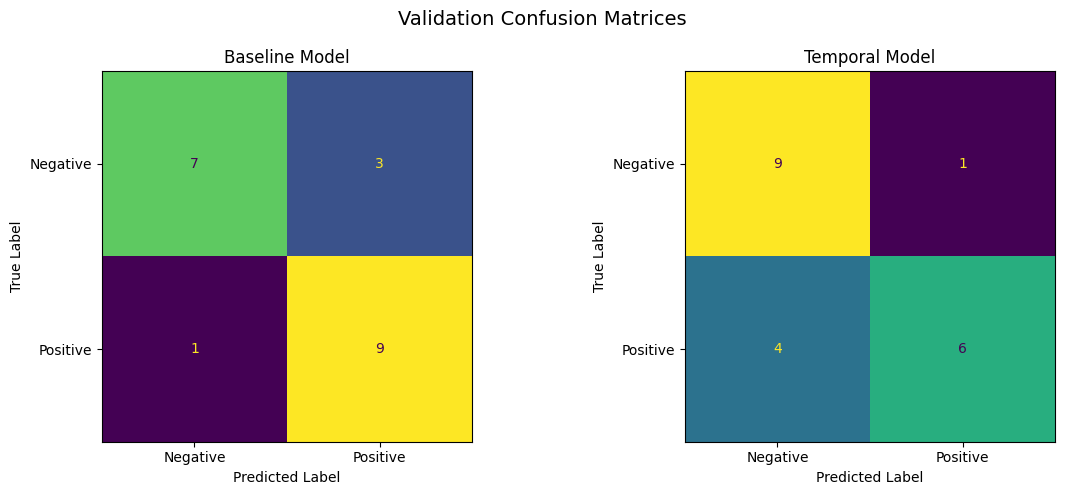

Saved confusion matrices: /content/drive/MyDrive/AI_Project2/outputs/cv/model_confusion_matrices.png


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

CONFUSION_MATRICES_PATH = (
    CV_OUTPUT_DIR / "model_confusion_matrices.png"
)

models = {
    "Baseline": baseline_df,
    "Temporal": temporal_df,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for axis, (model_name, dataframe) in zip(axes, models.items()):
    cm = confusion_matrix(
        dataframe["true_label"],
        dataframe["predicted_label"],
        labels=["negative", "positive"]
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    display_matrix.plot(
        ax=axis,
        values_format="d",
        colorbar=False
    )

    axis.set_title(f"{model_name} Model")
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("True Label")

    print(f"{model_name} confusion matrix:")
    print(cm)
    print()

fig.suptitle(
    "Validation Confusion Matrices",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRICES_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved confusion matrices:", CONFUSION_MATRICES_PATH)

<div dir="rtl" align="right">

## ۶. تحلیل False Positive و False Negative دو مدل

در این مرحله خطاهای هر دو مدل در سطح ویدئو استخراج می‌شوند.

برای هر خطا اطلاعات زیر ثبت خواهد شد:

- شناسه ویدئو
- مدل
- برچسب واقعی
- برچسب پیش‌بینی‌شده
- احتمال کلاس تصادف
- نوع خطا
- میزان اطمینان مدل

همچنین مشخص می‌شود هر ویدئو:

- توسط هر دو مدل درست تشخیص داده شده است.
- فقط توسط مدل پایه درست تشخیص داده شده است.
- فقط توسط مدل زمانی درست تشخیص داده شده است.
- توسط هر دو مدل اشتباه تشخیص داده شده است.

خروجی در مسیر زیر ذخیره می‌شود:

`outputs/cv/model_error_analysis.csv`

</div>

In [6]:
MODEL_ERROR_ANALYSIS_PATH = (
    CV_OUTPUT_DIR / "model_error_analysis.csv"
)

model_dataframes = {
    "Baseline": baseline_df,
    "Temporal": temporal_df,
}

error_records = []

for model_name, dataframe in model_dataframes.items():
    model_errors = dataframe[
        dataframe["true_label"] != dataframe["predicted_label"]
    ].copy()

    model_errors["model"] = model_name

    model_errors["error_type"] = np.where(
        model_errors["true_label"] == "positive",
        "False Negative",
        "False Positive"
    )

    model_errors["prediction_confidence"] = np.where(
        model_errors["predicted_label"] == "positive",
        model_errors["positive_probability"],
        1 - model_errors["positive_probability"]
    )

    error_records.append(
        model_errors[
            [
                "video_id",
                "model",
                "true_label",
                "predicted_label",
                "positive_probability",
                "prediction_confidence",
                "error_type",
            ]
        ]
    )

model_error_analysis_df = pd.concat(
    error_records,
    ignore_index=True
).sort_values(
    by=["error_type", "model", "prediction_confidence"],
    ascending=[True, True, False]
).reset_index(drop=True)

model_error_analysis_df.to_csv(
    MODEL_ERROR_ANALYSIS_PATH,
    index=False
)

video_comparison_df = baseline_df[
    ["video_id", "true_label", "predicted_label"]
].merge(
    temporal_df[
        ["video_id", "predicted_label"]
    ],
    on="video_id",
    suffixes=("_baseline", "_temporal"),
    validate="one_to_one"
)

video_comparison_df["baseline_correct"] = (
    video_comparison_df["true_label"]
    == video_comparison_df["predicted_label_baseline"]
)

video_comparison_df["temporal_correct"] = (
    video_comparison_df["true_label"]
    == video_comparison_df["predicted_label_temporal"]
)

video_comparison_df["comparison_status"] = np.select(
    [
        video_comparison_df["baseline_correct"]
        & video_comparison_df["temporal_correct"],

        video_comparison_df["baseline_correct"]
        & ~video_comparison_df["temporal_correct"],

        ~video_comparison_df["baseline_correct"]
        & video_comparison_df["temporal_correct"],
    ],
    [
        "Both Correct",
        "Only Baseline Correct",
        "Only Temporal Correct",
    ],
    default="Both Wrong"
)

print("Error summary:")
print(
    model_error_analysis_df.groupby(
        ["model", "error_type"]
    ).size()
)

print("\nVideo-level comparison:")
print(
    video_comparison_df["comparison_status"]
    .value_counts()
)

print("\nDetailed errors:")
display(model_error_analysis_df)

print("Saved error analysis:", MODEL_ERROR_ANALYSIS_PATH)

Error summary:
model     error_type    
Baseline  False Negative    1
          False Positive    3
Temporal  False Negative    4
          False Positive    1
dtype: int64

Video-level comparison:
comparison_status
Both Correct             13
Only Baseline Correct     3
Both Wrong                2
Only Temporal Correct     2
Name: count, dtype: int64

Detailed errors:


,video_id,model,true_label,predicted_label,positive_probability,prediction_confidence,error_type
0,00037,Baseline,positive,negative,0.495432,0.504568,False Negative
1,00037,Temporal,positive,negative,0.185006,0.814994,False Negative
2,00032,Temporal,positive,negative,0.278372,0.721628,False Negative
3,00059,Temporal,positive,negative,0.309050,0.690950,False Negative
4,00008,Temporal,positive,negative,0.450362,0.549638,False Negative
5,01081,Baseline,negative,positive,0.711947,0.711947,False Positive
6,01116,Baseline,negative,positive,0.614347,0.614347,False Positive
7,01103,Baseline,negative,positive,0.580255,0.580255,False Positive
8,01081,Temporal,negative,positive,0.764295,0.764295,False Positive


Saved error analysis: /content/drive/MyDrive/AI_Project2/outputs/cv/model_error_analysis.csv


<div dir="rtl" align="right">

## ۷. انتخاب مدل نهایی و ذخیره جمع‌بندی ارزیابی

مدل پایه به‌عنوان مدل نهایی انتخاب می‌شود؛ زیرا:

- Accuracy بالاتری دارد: `0.80` در برابر `0.75`
- Recall بالاتری دارد: `0.90` در برابر `0.60`
- F1-score بالاتری دارد: `0.8182` در برابر `0.7059`
- فقط یک تصادف واقعی را از دست داده است، درحالی‌که مدل زمانی چهار False Negative دارد.

مدل زمانی Precision بالاتری دارد و هشدار اشتباه کمتری تولید می‌کند؛ اما در مسئله تشخیص تصادف، ازدست‌دادن تصادف واقعی معمولاً خطای مهم‌تری محسوب می‌شود.

با توجه به اینکه Validation فقط شامل ۲۰ ویدئو است، این انتخاب باید به‌عنوان نتیجه همین مجموعه محدود در نظر گرفته شود.

</div>

In [7]:
FINAL_SELECTION_PATH = (
    CV_OUTPUT_DIR / "final_model_selection.csv"
)

VIDEO_COMPARISON_PATH = (
    CV_OUTPUT_DIR / "model_video_level_comparison.csv"
)

EVALUATION_SUMMARY_PATH = (
    CV_OUTPUT_DIR / "model_evaluation_summary.txt"
)

# ذخیره مقایسه ویدئو به ویدئو
video_comparison_df.to_csv(
    VIDEO_COMPARISON_PATH,
    index=False
)

baseline_metrics = comparison_metrics_df[
    comparison_metrics_df["model"] == "Baseline"
].iloc[0]

temporal_metrics = comparison_metrics_df[
    comparison_metrics_df["model"] == "Temporal"
].iloc[0]

final_selection_df = pd.DataFrame([{
    "selected_model": "Baseline",
    "model_path": "models/cv/baseline_model.pth",
    "selection_metric": "F1 Score with priority on Recall",
    "validation_samples": int(
        baseline_metrics["validation_samples"]
    ),
    "accuracy": baseline_metrics["accuracy"],
    "precision": baseline_metrics["precision"],
    "recall": baseline_metrics["recall"],
    "f1_score": baseline_metrics["f1_score"],
    "false_positive": int(
        baseline_metrics["false_positive"]
    ),
    "false_negative": int(
        baseline_metrics["false_negative"]
    ),
    "selection_reason": (
        "Higher Accuracy, Recall and F1 Score, "
        "with fewer missed collision videos."
    ),
}])

final_selection_df.to_csv(
    FINAL_SELECTION_PATH,
    index=False
)

summary_text = f"""
CV Model Evaluation Summary
===========================

Validation samples: 20
Positive videos: 10
Negative videos: 10

Baseline Model
--------------
Accuracy: {baseline_metrics['accuracy']:.4f}
Precision: {baseline_metrics['precision']:.4f}
Recall: {baseline_metrics['recall']:.4f}
F1 Score: {baseline_metrics['f1_score']:.4f}
False Positive: {int(baseline_metrics['false_positive'])}
False Negative: {int(baseline_metrics['false_negative'])}

Temporal Model
--------------
Accuracy: {temporal_metrics['accuracy']:.4f}
Precision: {temporal_metrics['precision']:.4f}
Recall: {temporal_metrics['recall']:.4f}
F1 Score: {temporal_metrics['f1_score']:.4f}
False Positive: {int(temporal_metrics['false_positive'])}
False Negative: {int(temporal_metrics['false_negative'])}

Error Comparison
----------------
Both correct: 13
Only baseline correct: 3
Only temporal correct: 2
Both wrong: 2

Final Selected Model
--------------------
Selected model: Baseline
Model path: models/cv/baseline_model.pth

Reason:
The Baseline model achieved higher Accuracy, Recall and F1 Score.
It missed only one real collision, compared with four missed
collisions by the Temporal model.

Limitation:
The comparison is based on only 20 validation videos.
""".strip()

EVALUATION_SUMMARY_PATH.write_text(
    summary_text,
    encoding="utf-8"
)

display(final_selection_df)

print("Selected model: Baseline")
print("Saved final selection:", FINAL_SELECTION_PATH)
print("Saved video comparison:", VIDEO_COMPARISON_PATH)
print("Saved evaluation summary:", EVALUATION_SUMMARY_PATH)

,selected_model,model_path,selection_metric,validation_samples,accuracy,precision,recall,f1_score,false_positive,false_negative,selection_reason
0,Baseline,models/cv/baseline_model.pth,F1 Score with priority on Recall,20,0.8,0.75,0.9,0.818182,3,1,"Higher Accuracy, Recall and F1 Score, with few..."


Selected model: Baseline
Saved final selection: /content/drive/MyDrive/AI_Project2/outputs/cv/final_model_selection.csv
Saved video comparison: /content/drive/MyDrive/AI_Project2/outputs/cv/model_video_level_comparison.csv
Saved evaluation summary: /content/drive/MyDrive/AI_Project2/outputs/cv/model_evaluation_summary.txt


<div dir="rtl" align="right">

## ۸. بررسی نهایی خروجی‌های ارزیابی

در این مرحله وجود تمام خروجی‌های موردنیاز ارزیابی بررسی می‌شود:

- جدول مقایسه مدل‌ها
- Confusion Matrix
- معیارهای Accuracy، Precision، Recall و F1
- تحلیل False Positive و False Negative
- مقایسه ویدئو به ویدئو
- انتخاب مدل نهایی
- گزارش خلاصه ارزیابی

</div>

In [8]:
required_evaluation_outputs = {
    "Model comparison metrics":
        CV_OUTPUT_DIR / "model_comparison_metrics.csv",

    "Confusion matrices":
        CV_OUTPUT_DIR / "model_confusion_matrices.png",

    "False Positive and False Negative analysis":
        CV_OUTPUT_DIR / "model_error_analysis.csv",

    "Video-level comparison":
        CV_OUTPUT_DIR / "model_video_level_comparison.csv",

    "Final model selection":
        CV_OUTPUT_DIR / "final_model_selection.csv",

    "Evaluation summary":
        CV_OUTPUT_DIR / "model_evaluation_summary.txt",
}

all_outputs_exist = True

for output_name, output_path in required_evaluation_outputs.items():
    exists = output_path.is_file()
    all_outputs_exist &= exists

    status = "OK" if exists else "MISSING"

    print(f"{status:7} | {output_name}")
    print(f"          {output_path}")

assert all_outputs_exist, (
    "Some required evaluation outputs are missing."
)

print("\nEvaluation task is complete.")
print("Selected final model: Baseline")
print("Final model path: models/cv/baseline_model.pth")
print("Validation Accuracy: 0.8000")
print("Validation Precision: 0.7500")
print("Validation Recall: 0.9000")
print("Validation F1 Score: 0.8182")

OK      | Model comparison metrics
          /content/drive/MyDrive/AI_Project2/outputs/cv/model_comparison_metrics.csv
OK      | Confusion matrices
          /content/drive/MyDrive/AI_Project2/outputs/cv/model_confusion_matrices.png
OK      | False Positive and False Negative analysis
          /content/drive/MyDrive/AI_Project2/outputs/cv/model_error_analysis.csv
OK      | Video-level comparison
          /content/drive/MyDrive/AI_Project2/outputs/cv/model_video_level_comparison.csv
OK      | Final model selection
          /content/drive/MyDrive/AI_Project2/outputs/cv/final_model_selection.csv
OK      | Evaluation summary
          /content/drive/MyDrive/AI_Project2/outputs/cv/model_evaluation_summary.txt

Evaluation task is complete.
Selected final model: Baseline
Final model path: models/cv/baseline_model.pth
Validation Accuracy: 0.8000
Validation Precision: 0.7500
Validation Recall: 0.9000
Validation F1 Score: 0.8182
